# 1
- pure comp: molecular
- kij: molecular
- melting: molecular

In [1]:
using Pkg, Revise
using Clapeyron, PyCall
import PyPlot; const plt = PyPlot
import DataFrames

In [3]:
#Hfus dan Tm masukin ke csv yh jgn lupa

like_parameter1 = """Clapeyron Database File
PCSAFT Like Parameters [csvtype = like,grouptype = PCSAFT]
species,Mw,segment,sigma,epsilon,n_H,n_e
serine_held,105.09,7.0236,2.284,236.92,2,2
water,18.02,1.2047,2.801457,353.94,1,1
"""
# GC glycine1,75.07,4.8492,2.2140,238.6085,2,2 
# Held glycine1,75.07,4.8495,2.3270,216.9600,2,2 

unlike_parameter1 = """Clapeyron Database File
PCSAFT Unlike Parameters [csvtype = unlike,grouptype = PCSAFT]
species1,species2,k
water,serine_held,-0.0257
"""

# GC kij = 0.0000296035176
# Held kij = -0.0612

#jgn lupa combing rules yh
assoc_parameter1 = """Clapeyron Database File
PCSAFT Assoc Parameters [csvtype = assoc,grouptype = PCSAFT]
species1,site1,species2,site2,epsilon_assoc,bondvol
water,H,water,e,2425.67,0.045
serine_held,H,serine_held,e,2671.93,0.0385
water,H,serine_held,e,2548.8,0.041407
water,e,serine_held,H,2548.8,0.041407
"""
components = ["water", "serine_held"]
model1 = CompositeModel(components;
                       fluid = PCSAFT,
                       solid = SolidHfus,
                       fluid_userlocations = [like_parameter1, unlike_parameter1, assoc_parameter1])

println(model1.fluid.params.epsilon.values)
println(model1.fluid.params.sigma.values)
println("======================")
println(model1.fluid.params.epsilon_assoc.values)
println(model1.fluid.params.bondvol.values)
println("kij = ", (1  - ((model1.fluid.params.epsilon.values[2])/(sqrt(model1.fluid.params.epsilon.values[1] * model1.fluid.params.epsilon.values[4])))))
println("Hfus = ", model1.solid.params.Hfus[2])
println("Tm = ", model1.solid.params.Tm[2])

[353.94 297.0202373352122; 297.0202373352122 236.92]
[2.8014570000000003e-10 2.5427285e-10; 2.5427285e-10 2.2839999999999998e-10]
Clapeyron.Compressed4DMatrix{Float64, Vector{Float64}}[2425.67, 2548.8, 2548.8, 2671.93]
Clapeyron.Compressed4DMatrix{Float64, Vector{Float64}}[0.045, 0.041407, 0.041407, 0.0385]
kij = -0.025700000000000056
Hfus = 21965.59
Tm = 589.2



=== HASIL PERHITUNGAN MODEL ===
100×2 DataFrame
 Row │ Temperatur_K  Fraksi_Mol_Solute 
     │ Float64       Float64           
─────┼─────────────────────────────────
   1 │      270.0           0.00406051
   2 │      273.224         0.00479766
   3 │      276.448         0.00567063
   4 │      279.673         0.0067093
   5 │      282.897         0.00795231
   6 │      286.121         0.00945026
   7 │      289.345         0.0112699
   8 │      292.57          0.0134995
   9 │      295.794         0.0162534
  10 │      299.018         0.019672
  11 │      302.242         0.0239055
  12 │      305.467         0.0290643
  13 │      308.691         0.0351383
  14 │      311.915         0.0419483
  15 │      315.139         0.0492061
  16 │      318.364         0.0566404
  17 │      321.588         0.0640706
  18 │      324.812         0.0714042
  19 │      328.036         0.0786067
  20 │      331.261         0.0856744
  21 │      334.485         0.0926179
  22 │      337.709         0

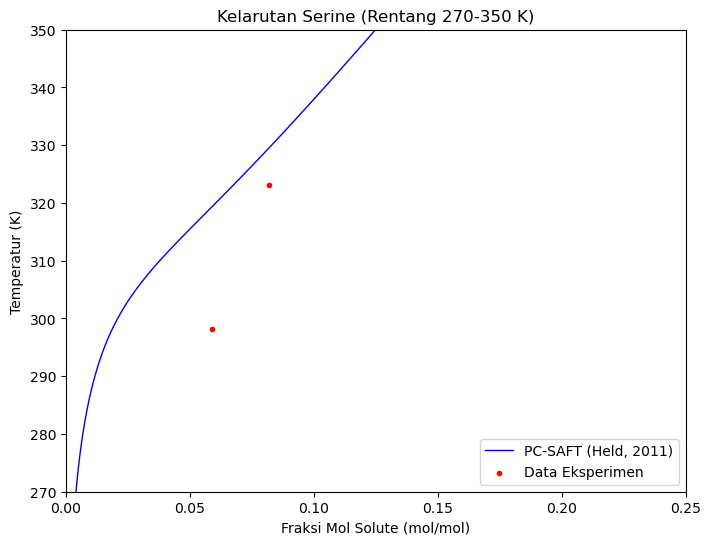

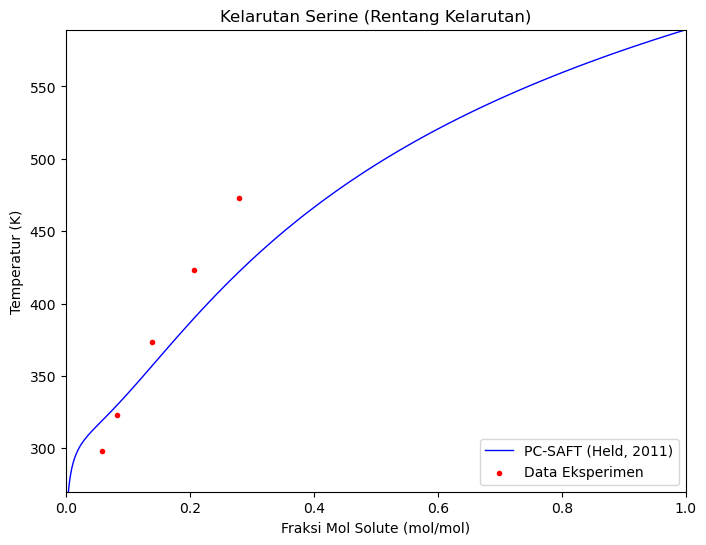

In [9]:
using Clapeyron
using CSV
using DataFrames

df_eksperimen = CSV.read("fig_serine.csv", DataFrame)

function plot_T(df)
    T = LinRange(270., 350., 100)
    p = 101325
    s = zeros(length(T))
    for i in 1:length(T)
        s[i] = sle_solubility(model1, p, T[i], [1., 1.]; solute=["serine_held"])[2]
    end

    plt.figure(figsize=(8, 6))
    
    plt.plot(s, T, label="PC-SAFT (Held, 2011)", color="blue", linewidth=1)

    plt.scatter(df.out_x2, df.T, label="Data Eksperimen", color="red", marker=".", zorder=1)
    
    plt.title("Kelarutan Serine (Rentang 270-350 K)")
    plt.xlabel("Fraksi Mol Solute (mol/mol)")
    plt.ylabel("Temperatur (K)")
    
    plt.xlim(0.0, 0.25)
    plt.ylim(270.0, 350.0)
    
    plt.legend(loc="lower right")
    plt.savefig("1_plot_T_serine.png", dpi=450, bbox_inches="tight") #GANTI NAMANYA DULU
end

function plot_x(df)
    T = LinRange(270., model1.solid.params.Tm[2], 100)
    p = 101325 
    s = zeros(length(T))
    for i in 1:length(T)
        s[i] = sle_solubility(model1, p, T[i], [1., 1.]; solute=["serine_held"])[2]
    end

    # Bikin DataFrame-nya dulu
    df_hasil = DataFrame(Temperatur_K = T, Fraksi_Mol_Solute = s)
    # Tampilkan di output terminal
    println("\n=== HASIL PERHITUNGAN MODEL ===")
    show(df_hasil, allrows=true)
    println("\n")

    plt.figure(figsize=(8, 6))
    
    plt.plot(s, T, label="PC-SAFT (Held, 2011)", color="blue", linewidth=1)

    plt.scatter(df.out_x2, df.T, label="Data Eksperimen", color="red", marker=".", zorder=1)
    
    plt.title("Kelarutan Serine (Rentang Kelarutan)")
    plt.xlabel("Fraksi Mol Solute (mol/mol)")
    plt.ylabel("Temperatur (K)")
    
    plt.xlim(0.0, 1)
    plt.ylim(270.0, model1.solid.params.Tm[2])
    
    plt.legend(loc="lower right")
    plt.savefig("1_plot_x_serine.png", dpi=450, bbox_inches="tight") #GANTI NAMANYA DULU
end

plot_T(df_eksperimen)
plot_x(df_eksperimen)

In [7]:
using CSV, DataFrames, Printf

function solubility_gclow(model::EoSModel, T::Float64)
    p = 101325
    x2 = sle_solubility(model,p,T,[1.,1.];solute=["serine_gclow"])[2]
    return x2
end

function solubility_gcmid(model::EoSModel, T::Float64)
    p = 101325
    x2 = sle_solubility(model,p,T,[1.,1.];solute=["serine_gcmid"])[2]
    return x2
end

function solubility_gcup(model::EoSModel, T::Float64)
    p = 101325
    x2 = sle_solubility(model,p,T,[1.,1.];solute=["serine_gcup"])[2]
    return x2
end

function solubility_held(model::EoSModel, T::Float64)
    p = 101325
    x2 = sle_solubility(model,p,T,[1.,1.];solute=["serine_held"])[2]
    return x2
end

function calculate_AAD(model, csv_file, property_func)
    df = CSV.read(csv_file, DataFrame, comment="#", skipto=4)
    
    input_col  = names(df)[1]          # first column = input (T)
    output_col = names(df)[2]          # second column = out_xxx (experimental)
    
    inputs   = df[!, input_col]
    exp_vals = df[!, output_col]
    
    println("\n=== AAD: $csv_file ===")
    @printf("%-10s  %-12s  %-12s  %-8s\n", input_col, "exp", "calc", "ARD%")
    
    errors = Float64[]
    for (i, x) in enumerate(inputs)
        calc = property_func(model, x)
        err  = abs(calc - exp_vals[i]) / abs(exp_vals[i]) * 100
        push!(errors, err)
        @printf("%-10.4f  %-12.6f  %-12.6f  %-8.4f\n", x, exp_vals[i], calc, err)
    end
    
    aard = sum(errors) / length(errors)
    @printf("AARD = %.4f%%\n", aard)
    return aard
end

calculate_AAD (generic function with 1 method)

In [8]:
aard_p   = calculate_AAD(model1, "sol_serine.csv", solubility_held)

┌ Warning: thread = 1 warning: parsed expected 1 columns, but didn't reach end of line around data row: 1. Parsing extra columns and widening final columnset
└ @ CSV C:\Users\sutha\.julia\packages\CSV\XLcqT\src\file.jl:593



=== AAD: sol_serine.csv ===
Clapeyron Estimator  exp           calc          ARD%    
298.1500    0.059009      0.018677      68.3482 
323.1500    0.081925      0.067639      17.4376 
373.1500    0.138613      0.171819      23.9556 
423.1500    0.207127      0.282135      36.2137 
473.1500    0.279037      0.421193      50.9454 
AARD = 39.3801%


39.380099598779495

# 2
- pure comp: GC
- kij: GC
- melting: GC

In [10]:
#Hfus dan Tm masukin ke csv yh jgn lupa

like_parameter2 = """Clapeyron Database File
PCSAFT Like Parameters [csvtype = like,grouptype = PCSAFT]
species,Mw,segment,sigma,epsilon,n_H,n_e
serine_gclow,105.09,7.0236,2.284,236.92,2,2
serine_gcmid,105.09,7.0236,2.284,236.92,2,2
serine_gcup,105.09,7.0236,2.284,236.92,2,2
water,18.02,1.2047,2.801457,353.94,1,1
"""
# GC glycine1,75.07,4.8492,2.2140,238.6085,2,2 
# Held glycine1,75.07,4.8495,2.3270,216.9600,2,2 

unlike_parameter2 = """Clapeyron Database File
PCSAFT Unlike Parameters [csvtype = unlike,grouptype = PCSAFT]
species1,species2,k
water,serine_gclow,0.190076
water,serine_gcmid,0.190076
water,serine_gcup,0.190076
"""

# GC kij = 0.0000296035176
# Held kij = -0.0612

#jgn lupa combing rules yh
assoc_parameter2 = """Clapeyron Database File
PCSAFT Assoc Parameters [csvtype = assoc,grouptype = PCSAFT]
species1,site1,species2,site2,epsilon_assoc,bondvol
water,H,water,e,2425.67,0.045
serine_gclow,H,serine_gclow,e,2086.933118,0.032905
serine_gcmid,H,serine_gcmid,e,2086.933118,0.032905
serine_gcup,H,serine_gcup,e,2086.933118,0.032905
water,H,serine_gclow,e,2256.302,0.037884
water,e,serine_gclow,H,2256.302,0.037884
water,H,serine_gcmid,e,2256.302,0.037884
water,e,serine_gcmid,H,2256.302,0.037884
water,H,serine_gcup,e,2256.302,0.037884
water,e,serine_gcup,H,2256.302,0.037884
"""
components_low = ["water", "serine_gclow"]
components_mid = ["water", "serine_gcmid"]
components_up = ["water", "serine_gcup"]

model2_low = CompositeModel(components_low;
                       fluid = PCSAFT,
                       solid = SolidHfus,
                       fluid_userlocations = [like_parameter2, unlike_parameter2, assoc_parameter2])
model2_mid = CompositeModel(components_mid;
                       fluid = PCSAFT,
                       solid = SolidHfus,
                       fluid_userlocations = [like_parameter2, unlike_parameter2, assoc_parameter2])
model2_up = CompositeModel(components_up;
                       fluid = PCSAFT,
                       solid = SolidHfus,
                       fluid_userlocations = [like_parameter2, unlike_parameter2, assoc_parameter2])


println("low bound")
println("Hfus = ", model2_low.solid.params.Hfus[2])
println("Tm = ", model2_low.solid.params.Tm[2])

println("mid bound")
println("Hfus = ", model2_mid.solid.params.Hfus[2])
println("Tm = ", model2_mid.solid.params.Tm[2])

println("up bound")
println("Hfus = ", model2_up.solid.params.Hfus[2])
println("Tm = ", model2_up.solid.params.Tm[2])

low bound
Hfus = 23931.34
Tm = 540.7812
mid bound
Hfus = 28626.0
Tm = 587.17
up bound
Hfus = 33320.66
Tm = 633.5536



=== HASIL PERHITUNGAN MODEL ===
100×4 DataFrame
 Row │ Temperatur_K  X_Low        X_Mid        X_Up        
     │ Float64       Float64      Float64      Float64     
─────┼─────────────────────────────────────────────────────
   1 │      270.0    5.5684e-10   1.18174e-10  2.31697e-11
   2 │      272.735  7.56624e-10  1.63976e-10  3.28313e-11
   3 │      275.47   1.02165e-9   2.26011e-10  4.61918e-11
   4 │      278.205  1.37115e-9   3.09501e-10  6.4543e-11
   5 │      280.941  1.82937e-9   4.21174e-10  8.95839e-11
   6 │      283.676  2.4268e-9    5.69653e-10  1.23536e-10
   7 │      286.411  3.20153e-9   7.65928e-10  1.69288e-10
   8 │      289.146  4.20088e-9   1.02393e-9   2.30573e-10
   9 │      291.881  5.48345e-9   1.36123e-9   3.12188e-10
  10 │      294.616  7.12136e-9   1.79986e-9   4.20266e-10
  11 │      297.352  9.20306e-9   2.36736e-9   5.62608e-10
  12 │      300.087  1.18365e-8   3.09794e-9   7.49083e-10
  13 │      302.822  1.51529e-8   4.0339e-9    9.92117e-10
  14 

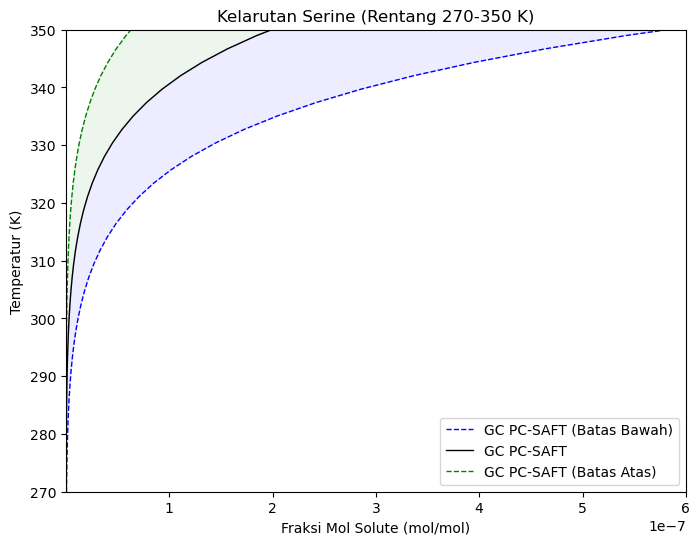

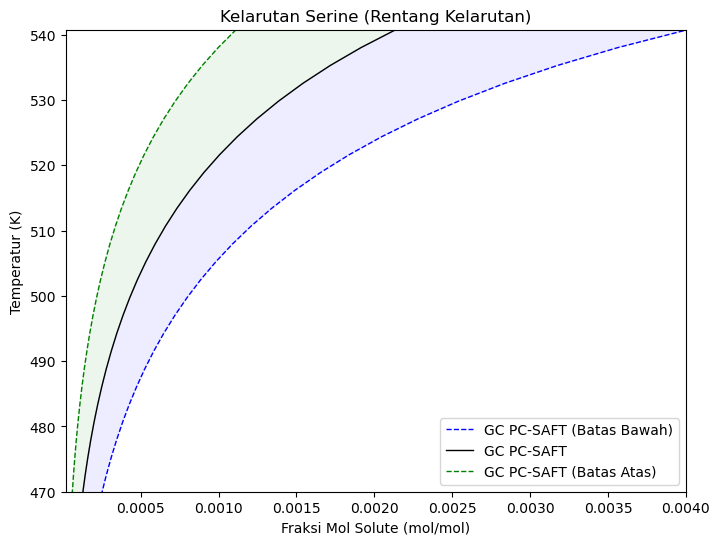

In [16]:
using Clapeyron
using CSV
using DataFrames

df_eksperimen = CSV.read("fig_serine.csv", DataFrame)

function plot_T(df)
    T = LinRange(270., 500., 100)
    p = 101325
    s_low = zeros(length(T))
    s_mid = zeros(length(T))
    s_up = zeros(length(T))

    
    for i in 1:length(T)
        s_low[i] = sle_solubility(model2_low, p, T[i], [1., 1.]; solute=["serine_gclow"])[2]
        s_mid[i] = sle_solubility(model2_mid, p, T[i], [1., 1.]; solute=["serine_gcmid"])[2]
        s_up[i]  = sle_solubility(model2_up, p, T[i], [1., 1.]; solute=["serine_gcup"])[2]
    end

    plt.figure(figsize=(8, 6))
    
    plt.plot(s_low, T, label="GC PC-SAFT (Batas Bawah)", color="blue", linestyle="--", linewidth=1.)
    plt.plot(s_mid, T, label="GC PC-SAFT", color="black", linestyle="-", linewidth=1.)
    plt.plot(s_up, T, label="GC PC-SAFT (Batas Atas)", color="green", linestyle="--", linewidth=1.)

    plt.fill_betweenx(T, s_mid, s_up, color="green", alpha=0.07)
    plt.fill_betweenx(T, s_low, s_mid, color="blue", alpha=0.07)

    plt.scatter(df.out_x2, df.T, color="red", marker=".", zorder=1)
    
    plt.title("Kelarutan Serine (Rentang 270-350 K)")
    plt.xlabel("Fraksi Mol Solute (mol/mol)")
    plt.ylabel("Temperatur (K)")
    
    plt.xlim(6.8e-15, 6e-7)
    plt.ylim(270.0, 350.0)
    
    plt.legend(loc="lower right")
    plt.savefig("2_plot_T_serine.png", dpi=450, bbox_inches="tight") #GANTI NAMANYA DULU
end


function plot_x(df)
    T = LinRange(270., model2_low.solid.params.Tm[2], 100)
    p = 101325
    
    s_low = zeros(length(T))
    s_mid = zeros(length(T))
    s_up = zeros(length(T))
    
    for i in 1:length(T)
        s_low[i] = sle_solubility(model2_low, p, T[i], [1., 1.]; solute=["serine_gclow"])[2]
        s_mid[i] = sle_solubility(model2_mid, p, T[i], [1., 1.]; solute=["serine_gcmid"])[2]
        s_up[i]  = sle_solubility(model2_up, p, T[i], [1., 1.]; solute=["serine_gcup"])[2]
    end


    # Bikin DataFrame-nya dulu
    df_hasil = DataFrame(
        Temperatur_K = T,
        X_Low = s_low,
        X_Mid = s_mid,
        X_Up = s_up)
    # Tampilkan di output terminal
    println("\n=== HASIL PERHITUNGAN MODEL ===")
    show(df_hasil, allrows=true)
    println("\n")

    plt.figure(figsize=(8, 6))
    
    plt.plot(s_low, T, label="GC PC-SAFT (Batas Bawah)", color="blue", linestyle="--", linewidth=1.)
    plt.plot(s_mid, T, label="GC PC-SAFT", color="black", linestyle="-", linewidth=1.)
    plt.plot(s_up, T, label="GC PC-SAFT (Batas Atas)", color="green", linestyle="--", linewidth=1.)

    plt.fill_betweenx(T, s_mid, s_up, color="green", alpha=0.07)
    plt.fill_betweenx(T, s_low, s_mid, color="blue", alpha=0.07)

    plt.scatter(df.out_x2, df.T, color="red", marker=".", zorder=1)
    
    plt.title("Kelarutan Serine (Rentang Kelarutan)")
    plt.xlabel("Fraksi Mol Solute (mol/mol)")
    plt.ylabel("Temperatur (K)")
    
    plt.xlim(2e-5, 0.004)
    plt.ylim(470, model2_low.solid.params.Tm[2])
    
    plt.legend(loc="lower right")
    plt.savefig("2_plot_x_serine.png", dpi=450, bbox_inches="tight") #GANTI NAMANYA DULU
end

plot_T(df_eksperimen)
plot_x(df_eksperimen)

In [17]:
aard_p   = calculate_AAD(model2_low, "sol_serine.csv", solubility_gclow)


=== AAD: sol_serine.csv ===
Clapeyron Estimator  exp           calc          ARD%    
298.1500    0.059009      0.000000      100.0000
323.1500    0.081925      0.000000      99.9999 
373.1500    0.138613      0.000002      99.9982 
423.1500    0.207127      0.000034      99.9836 
473.1500    0.279037      0.000286      99.8974 
AARD = 99.9758%


┌ Warning: thread = 1 warning: parsed expected 1 columns, but didn't reach end of line around data row: 1. Parsing extra columns and widening final columnset
└ @ CSV C:\Users\sutha\.julia\packages\CSV\XLcqT\src\file.jl:593


99.97583192880423

In [18]:
aard_p   = calculate_AAD(model2_mid, "sol_serine.csv", solubility_gcmid)


=== AAD: sol_serine.csv ===
Clapeyron Estimator  exp           calc          ARD%    
298.1500    0.059009      0.000000      100.0000
323.1500    0.081925      0.000000      100.0000
373.1500    0.138613      0.000001      99.9993 
423.1500    0.207127      0.000015      99.9926 
473.1500    0.279037      0.000147      99.9472 
AARD = 99.9878%


┌ Warning: thread = 1 warning: parsed expected 1 columns, but didn't reach end of line around data row: 1. Parsing extra columns and widening final columnset
└ @ CSV C:\Users\sutha\.julia\packages\CSV\XLcqT\src\file.jl:593


99.98782129567635

In [19]:
aard_p   = calculate_AAD(model2_up, "sol_serine.csv", solubility_gcup)


=== AAD: sol_serine.csv ===
Clapeyron Estimator  exp           calc          ARD%    
298.1500    0.059009      0.000000      100.0000
323.1500    0.081925      0.000000      100.0000
373.1500    0.138613      0.000000      99.9998 
423.1500    0.207127      0.000006      99.9969 
473.1500    0.279037      0.000070      99.9748 
AARD = 99.9943%


┌ Warning: thread = 1 warning: parsed expected 1 columns, but didn't reach end of line around data row: 1. Parsing extra columns and widening final columnset
└ @ CSV C:\Users\sutha\.julia\packages\CSV\XLcqT\src\file.jl:593


99.9942861313745

# 3
- pure comp: GC
- kij: GC
- melting: molecular

In [20]:
#Hfus dan Tm masukin ke csv yh jgn lupa

like_parameter3 = """Clapeyron Database File
PCSAFT Like Parameters [csvtype = like,grouptype = PCSAFT]
species,Mw,segment,sigma,epsilon,n_H,n_e
serine_held,105.09,7.0236,2.284,236.92,2,2
water,18.02,1.2047,2.801457,353.94,1,1
"""
# GC glycine1,75.07,4.8492,2.2140,238.6085,2,2 
# Held glycine1,75.07,4.8495,2.3270,216.9600,2,2 

unlike_parameter3 = """Clapeyron Database File
PCSAFT Unlike Parameters [csvtype = unlike,grouptype = PCSAFT]
species1,species2,k
water,serine_held,0.185853
"""

# GC kij = 0.0000296035176
# Held kij = -0.0612

#jgn lupa combing rules yh
assoc_parameter3 = """Clapeyron Database File
PCSAFT Assoc Parameters [csvtype = assoc,grouptype = PCSAFT]
species1,site1,species2,site2,epsilon_assoc,bondvol
water,H,water,e,2425.67,0.045
serine_held,H,serine_held,e,2086.933118,0.032905
water,H,serine_held,e,2256.302,0.037884
water,e,serine_held,H,2256.302,0.037884
"""
components = ["water", "serine_held"]
model3 = CompositeModel(components;
                       fluid = PCSAFT,
                       solid = SolidHfus,
                       fluid_userlocations = [like_parameter3, unlike_parameter3, assoc_parameter3])

println(model3.fluid.params.epsilon.values)
println(model3.fluid.params.sigma.values)
println("======================")
println(model3.fluid.params.epsilon_assoc.values)
println(model3.fluid.params.bondvol.values)
println("kij = ", (1  - ((model3.fluid.params.epsilon.values[2])/(sqrt(model3.fluid.params.epsilon.values[1] * model3.fluid.params.epsilon.values[4])))))
println("Hfus = ", model3.solid.params.Hfus[2])
println("Tm = ", model3.solid.params.Tm[2])

[353.94 235.75912563688306; 235.75912563688306 236.92]
[2.8014570000000003e-10 2.5427285e-10; 2.5427285e-10 2.2839999999999998e-10]
Clapeyron.Compressed4DMatrix{Float64, Vector{Float64}}[2425.67, 2256.302, 2256.302, 2086.933118]
Clapeyron.Compressed4DMatrix{Float64, Vector{Float64}}[0.045, 0.037884, 0.037884, 0.032905]
kij = 0.18585300000000005
Hfus = 21965.59
Tm = 589.2



=== HASIL PERHITUNGAN MODEL ===
100×2 DataFrame
 Row │ Temperatur_K  Fraksi_Mol_Solute 
     │ Float64       Float64           
─────┼─────────────────────────────────
   1 │      270.0          7.81627e-10
   2 │      273.224        1.10502e-9
   3 │      276.448        1.54925e-9
   4 │      279.673        2.15468e-9
   5 │      282.897        2.97356e-9
   6 │      286.121        4.0731e-9
   7 │      289.345        5.53911e-9
   8 │      292.57         7.48049e-9
   9 │      295.794        1.00346e-8
  10 │      299.018        1.33736e-8
  11 │      302.242        1.77121e-8
  12 │      305.467        2.33162e-8
  13 │      308.691        3.05138e-8
  14 │      311.915        3.97074e-8
  15 │      315.139        5.13881e-8
  16 │      318.364        6.61526e-8
  17 │      321.588        8.47223e-8
  18 │      324.812        1.07966e-7
  19 │      328.036        1.36925e-7
  20 │      331.261        1.72842e-7
  21 │      334.485        2.17196e-7
  22 │      337.709        2.7173

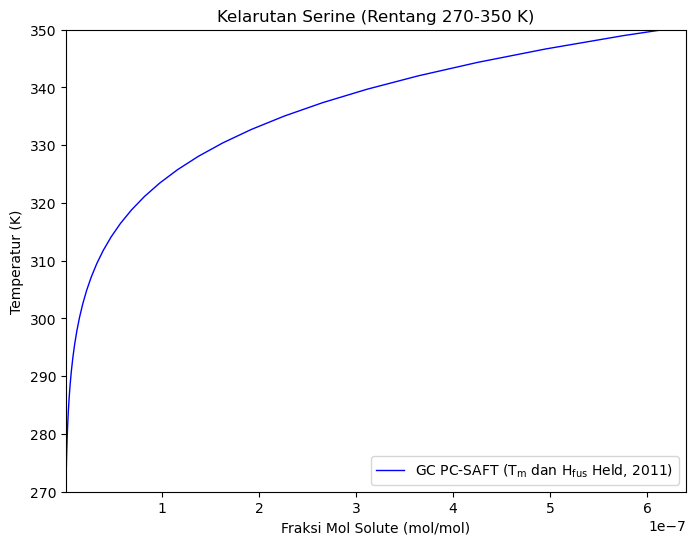

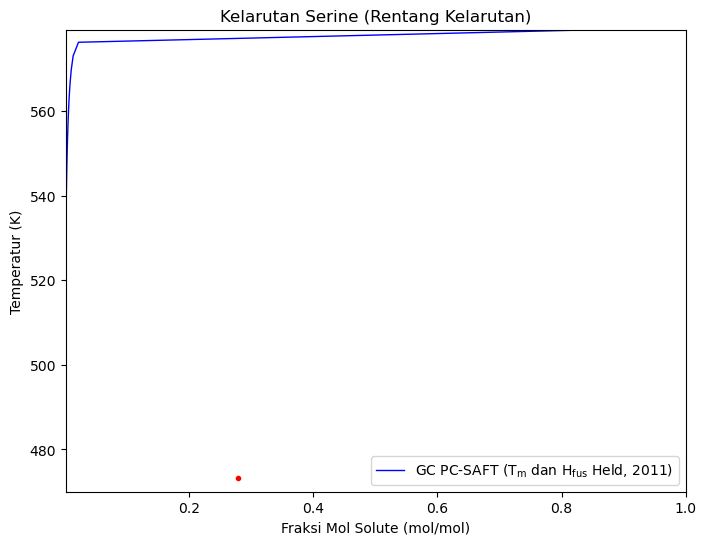

In [24]:
using Clapeyron
using CSV
using DataFrames
using LaTeXStrings

df_eksperimen = CSV.read("fig_serine.csv", DataFrame)

function plot_T(df)
    T = LinRange(270., 500., 100)
    p = 101325
    s = zeros(length(T))
    for i in 1:length(T)
        s[i] = sle_solubility(model3, p, T[i], [1., 1.]; solute=["serine_held"])[2]
    end

    plt.figure(figsize=(8, 6))
    
    plt.plot(s, T, label=L"GC PC-SAFT ($\text{T}_{\text{m}}$ dan $\text{H}_{\text{fus}}$ Held, 2011)", color="blue", linewidth=1)

    plt.scatter(df.out_x2, df.T, color="red", marker=".", zorder=1)
    
    plt.title("Kelarutan Serine (Rentang 270-350 K)")
    plt.xlabel("Fraksi Mol Solute (mol/mol)")
    plt.ylabel("Temperatur (K)")
    
    plt.xlim(7.8e-10, 6.4e-7)
    plt.ylim(270.0, 350.0)
    
    plt.legend(loc="lower right")
    plt.savefig("3_plot_T_serine.png", dpi=450, bbox_inches="tight") #GANTI NAMANYA DULU
end

function plot_x(df)
    T = LinRange(270., model3.solid.params.Tm[2], 100)
    p = 101325 
    s = zeros(length(T))
    for i in 1:length(T)
        s[i] = sle_solubility(model3, p, T[i], [1., 1.]; solute=["serine_held"])[2]
    end

    # Bikin DataFrame-nya dulu
    df_hasil = DataFrame(Temperatur_K = T, Fraksi_Mol_Solute = s)
    # Tampilkan di output terminal
    println("\n=== HASIL PERHITUNGAN MODEL ===")
    show(df_hasil, allrows=true)
    println("\n")

    plt.figure(figsize=(8, 6))
    
    plt.plot(s, T, label=L"GC PC-SAFT ($\text{T}_{\text{m}}$ dan $\text{H}_{\text{fus}}$ Held, 2011)", color="blue", linewidth=1)

    plt.scatter(df.out_x2, df.T, color="red", marker=".", zorder=1)
    
    plt.title("Kelarutan Serine (Rentang Kelarutan)")
    plt.xlabel("Fraksi Mol Solute (mol/mol)")
    plt.ylabel("Temperatur (K)")
    
    plt.xlim(0.002, 1.0)
    plt.ylim(470.0, 579.27)
    
    plt.legend(loc="lower right")
    plt.savefig("3_plot_x_serine.png", dpi=450, bbox_inches="tight") #GANTI NAMANYA DULU
end

plot_T(df_eksperimen)
plot_x(df_eksperimen)

In [25]:
aard_p   = calculate_AAD(model3, "sol_serine.csv", solubility_held)


=== AAD: sol_serine.csv ===
Clapeyron Estimator  exp           calc          ARD%    
298.1500    0.059009      0.000000      100.0000
323.1500    0.081925      0.000000      99.9999 
373.1500    0.138613      0.000002      99.9982 
423.1500    0.207127      0.000030      99.9853 
473.1500    0.279037      0.000235      99.9157 
AARD = 99.9798%


┌ Warning: thread = 1 warning: parsed expected 1 columns, but didn't reach end of line around data row: 1. Parsing extra columns and widening final columnset
└ @ CSV C:\Users\sutha\.julia\packages\CSV\XLcqT\src\file.jl:593


99.97982163265246

# 4
- pure comp: GC
- kij: molecular
- melting: GC

In [26]:
#Hfus dan Tm masukin ke csv yh jgn lupa

like_parameter4 = """Clapeyron Database File
PCSAFT Like Parameters [csvtype = like,grouptype = PCSAFT]
species,Mw,segment,sigma,epsilon,n_H,n_e
serine_gclow,105.09,7.0236,2.284,236.92,2,2
serine_gcmid,105.09,7.0236,2.284,236.92,2,2
serine_gcup,105.09,7.0236,2.284,236.92,2,2
water,18.02,1.2047,2.801457,353.94,1,1
"""
# GC glycine1,75.07,4.8492,2.2140,238.6085,2,2 
# Held glycine1,75.07,4.8495,2.3270,216.9600,2,2 

unlike_parameter4 = """Clapeyron Database File
PCSAFT Unlike Parameters [csvtype = unlike,grouptype = PCSAFT]
species1,species2,k
water,serine_gclow,-0.0257
water,serine_gcmid,-0.0257
water,serine_gcup,-0.0257
"""

# GC kij = 0.0000296035176
# Held kij = -0.0612

#jgn lupa combing rules yh
assoc_parameter4 = """Clapeyron Database File
PCSAFT Assoc Parameters [csvtype = assoc,grouptype = PCSAFT]
species1,site1,species2,site2,epsilon_assoc,bondvol
water,H,water,e,2425.67,0.045
serine_gclow,H,serine_gclow,e,2086.933118,0.032905
serine_gcmid,H,serine_gcmid,e,2086.933118,0.032905
serine_gcup,H,serine_gcup,e,2086.933118,0.032905
water,H,serine_gclow,e,2256.302,0.037884
water,e,serine_gclow,H,2256.302,0.037884
water,H,serine_gcmid,e,2256.302,0.037884
water,e,serine_gcmid,H,2256.302,0.037884
water,H,serine_gcup,e,2256.302,0.037884
water,e,serine_gcup,H,2256.302,0.037884
"""
components_low = ["water", "serine_gclow"]
components_mid = ["water", "serine_gcmid"]
components_up = ["water", "serine_gcup"]

model4_low = CompositeModel(components_low;
                       fluid = PCSAFT,
                       solid = SolidHfus,
                       fluid_userlocations = [like_parameter4, unlike_parameter4, assoc_parameter4])
model4_mid = CompositeModel(components_mid;
                       fluid = PCSAFT,
                       solid = SolidHfus,
                       fluid_userlocations = [like_parameter4, unlike_parameter4, assoc_parameter4])
model4_up = CompositeModel(components_up;
                       fluid = PCSAFT,
                       solid = SolidHfus,
                       fluid_userlocations = [like_parameter4, unlike_parameter4, assoc_parameter4])


println("low bound")
println("Hfus = ", model4_low.solid.params.Hfus[2])
println("Tm = ", model4_low.solid.params.Tm[2])

println("mid bound")
println("Hfus = ", model4_mid.solid.params.Hfus[2])
println("Tm = ", model4_mid.solid.params.Tm[2])

println("up bound")
println("Hfus = ", model4_up.solid.params.Hfus[2])
println("Tm = ", model4_up.solid.params.Tm[2])

low bound
Hfus = 23931.34
Tm = 540.7812
mid bound
Hfus = 28626.0
Tm = 587.17
up bound
Hfus = 33320.66
Tm = 633.5536



=== HASIL PERHITUNGAN MODEL ===
100×4 DataFrame
 Row │ Temperatur_K  X_Low       X_Mid        X_Up        
     │ Float64       Float64     Float64      Float64     
─────┼────────────────────────────────────────────────────
   1 │      270.0    0.00349583  0.000650738  0.00012439
   2 │      272.735  0.00404718  0.000756453  0.000147146
   3 │      275.47   0.00468502  0.000877089  0.000173479
   4 │      278.205  0.00542506  0.00101451   0.00020386
   5 │      280.941  0.00628682  0.0011708    0.000238811
   6 │      283.676  0.00729483  0.00134831   0.000278912
   7 │      286.411  0.00848024  0.00154968   0.000324802
   8 │      289.146  0.00988301  0.00177789   0.000377188
   9 │      291.881  0.0115548   0.00203633   0.000436851
  10 │      294.616  0.0135623   0.00232885   0.000504652
  11 │      297.352  0.0159909   0.00265984   0.000581541
  12 │      300.087  0.0189457   0.00303434   0.000668566
  13 │      302.822  0.0225451   0.00345817   0.000766882
  14 │      305.557  0

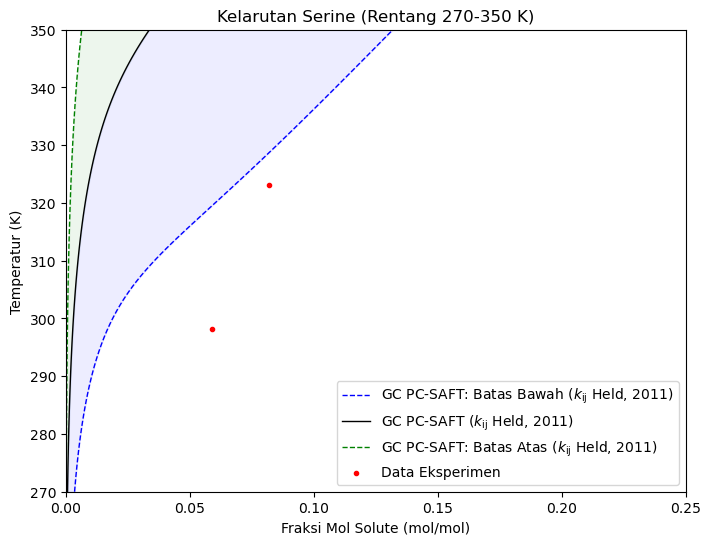

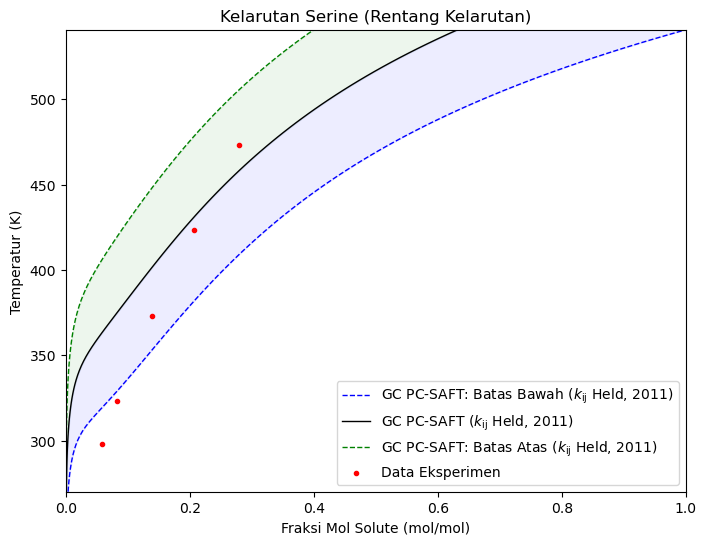

In [27]:
using Clapeyron
using CSV
using DataFrames
using LaTeXStrings

df_eksperimen = CSV.read("fig_serine.csv", DataFrame)

function plot_T(df)
    T = LinRange(270., 350., 100)
    p = 101325
    s_low = zeros(length(T))
    s_mid = zeros(length(T))
    s_up = zeros(length(T))

    
    for i in 1:length(T)
        s_low[i] = sle_solubility(model4_low, p, T[i], [1., 1.]; solute=["serine_gclow"])[2]
        s_mid[i] = sle_solubility(model4_mid, p, T[i], [1., 1.]; solute=["serine_gcmid"])[2]
        s_up[i]  = sle_solubility(model4_up, p, T[i], [1., 1.]; solute=["serine_gcup"])[2]
    end

    plt.figure(figsize=(8, 6))
    
    plt.plot(s_low, T, label=L"GC PC-SAFT: Batas Bawah ($k_{\text{ij}}$ Held, 2011)", color="blue", linestyle="--", linewidth=1.)
    plt.plot(s_mid, T, label=L"GC PC-SAFT ($k_{\text{ij}}$ Held, 2011)", color="black", linestyle="-", linewidth=1.)
    plt.plot(s_up, T, label=L"GC PC-SAFT: Batas Atas ($k_{\text{ij}}$ Held, 2011)", color="green", linestyle="--", linewidth=1.)

    plt.fill_betweenx(T, s_mid, s_up, color="green", alpha=0.07)
    plt.fill_betweenx(T, s_low, s_mid, color="blue", alpha=0.07)

    plt.scatter(df.out_x2, df.T, label="Data Eksperimen", color="red", marker=".", zorder=1)
    
    plt.title("Kelarutan Serine (Rentang 270-350 K)")
    plt.xlabel("Fraksi Mol Solute (mol/mol)")
    plt.ylabel("Temperatur (K)")
    
    plt.xlim(0.0, 0.25)
    plt.ylim(270.0, 350.0)
    
    plt.legend(loc="lower right")
    plt.savefig("4_plot_T_serine.png", dpi=450, bbox_inches="tight") #GANTI NAMANYA DULU
end

function plot_x(df)
    T = LinRange(270., model4_low.solid.params.Tm[2], 100)
    p = 101325
    
    s_low = zeros(length(T))
    s_mid = zeros(length(T))
    s_up = zeros(length(T))
    
    for i in 1:length(T)
        s_low[i] = sle_solubility(model4_low, p, T[i], [1., 1.]; solute=["serine_gclow"])[2]
        s_mid[i] = sle_solubility(model4_mid, p, T[i], [1., 1.]; solute=["serine_gcmid"])[2]
        s_up[i]  = sle_solubility(model4_up, p, T[i], [1., 1.]; solute=["serine_gcup"])[2]
    end

    # Bikin DataFrame-nya dulu
    df_hasil = DataFrame(
        Temperatur_K = T,
        X_Low = s_low,
        X_Mid = s_mid,
        X_Up = s_up)
    # Tampilkan di output terminal
    println("\n=== HASIL PERHITUNGAN MODEL ===")
    show(df_hasil, allrows=true)
    println("\n")

    plt.figure(figsize=(8, 6))
    
    plt.plot(s_low, T, label=L"GC PC-SAFT: Batas Bawah ($k_{\text{ij}}$ Held, 2011)", color="blue", linestyle="--", linewidth=1.)
    plt.plot(s_mid, T, label=L"GC PC-SAFT ($k_{\text{ij}}$ Held, 2011)", color="black", linestyle="-", linewidth=1.)
    plt.plot(s_up, T, label=L"GC PC-SAFT: Batas Atas ($k_{\text{ij}}$ Held, 2011)", color="green", linestyle="--", linewidth=1.)

    plt.fill_betweenx(T, s_mid, s_up, color="green", alpha=0.07)
    plt.fill_betweenx(T, s_low, s_mid, color="blue", alpha=0.07)

    plt.scatter(df.out_x2, df.T, label="Data Eksperimen", color="red", marker=".", zorder=1)
    
    plt.title("Kelarutan Serine (Rentang Kelarutan)")
    plt.xlabel("Fraksi Mol Solute (mol/mol)")
    plt.ylabel("Temperatur (K)")
    
    plt.xlim(0.0, 1)
    plt.ylim(270.0, model4_low.solid.params.Tm[2])
    
    plt.legend(loc="lower right")
    plt.savefig("4_plot_x_serine.png", dpi=450, bbox_inches="tight") #GANTI NAMANYA DULU
end

plot_T(df_eksperimen)
plot_x(df_eksperimen)

In [28]:
aard_p   = calculate_AAD(model4_low, "sol_serine.csv", solubility_gclow)


=== AAD: sol_serine.csv ===
Clapeyron Estimator  exp           calc          ARD%    
298.1500    0.059009      0.016794      71.5403 
323.1500    0.081925      0.068113      16.8591 
373.1500    0.138613      0.185748      34.0044 
423.1500    0.207127      0.322165      55.5399 
473.1500    0.279037      0.520151      86.4095 
AARD = 52.8706%


┌ Warning: thread = 1 warning: parsed expected 1 columns, but didn't reach end of line around data row: 1. Parsing extra columns and widening final columnset
└ @ CSV C:\Users\sutha\.julia\packages\CSV\XLcqT\src\file.jl:593


52.87062201843139

In [29]:
aard_p   = calculate_AAD(model4_mid, "sol_serine.csv", solubility_gcmid)


=== AAD: sol_serine.csv ===
Clapeyron Estimator  exp           calc          ARD%    
298.1500    0.059009      0.002764      95.3153 
323.1500    0.081925      0.009037      88.9692 
373.1500    0.138613      0.078769      43.1734 
423.1500    0.207127      0.187756      9.3521  
473.1500    0.279037      0.325640      16.7015 
AARD = 50.7023%


┌ Warning: thread = 1 warning: parsed expected 1 columns, but didn't reach end of line around data row: 1. Parsing extra columns and widening final columnset
└ @ CSV C:\Users\sutha\.julia\packages\CSV\XLcqT\src\file.jl:593


50.70228822298846

In [30]:
aard_p   = calculate_AAD(model4_up, "sol_serine.csv", solubility_gcup)

┌ Warning: thread = 1 warning: parsed expected 1 columns, but didn't reach end of line around data row: 1. Parsing extra columns and widening final columnset
└ @ CSV C:\Users\sutha\.julia\packages\CSV\XLcqT\src\file.jl:593



=== AAD: sol_serine.csv ===
Clapeyron Estimator  exp           calc          ARD%    
298.1500    0.059009      0.000606      98.9733 
323.1500    0.081925      0.002001      97.5572 
373.1500    0.138613      0.016813      87.8709 
423.1500    0.207127      0.089468      56.8053 
473.1500    0.279037      0.194142      30.4241 
AARD = 74.3262%


74.32616530714114

# 5
- pure comp: GC
- kij: 0
- melting: GC

In [31]:
#Hfus dan Tm masukin ke csv yh jgn lupa

like_parameter5 = """Clapeyron Database File
PCSAFT Like Parameters [csvtype = like,grouptype = PCSAFT]
species,Mw,segment,sigma,epsilon,n_H,n_e
serine_gclow,105.09,7.0236,2.284,236.92,2,2
serine_gcmid,105.09,7.0236,2.284,236.92,2,2
serine_gcup,105.09,7.0236,2.284,236.92,2,2
water,18.02,1.2047,2.801457,353.94,1,1
"""
# GC glycine1,75.07,4.8492,2.2140,238.6085,2,2 
# Held glycine1,75.07,4.8495,2.3270,216.9600,2,2 

unlike_parameter5 = """Clapeyron Database File
PCSAFT Unlike Parameters [csvtype = unlike,grouptype = PCSAFT]
species1,species2,k
water,serine_gclow,0
water,serine_gcmid,0
water,serine_gcup,0
"""

# GC kij = 0.0000296035176
# Held kij = -0.0612

#jgn lupa combing rules yh
assoc_parameter5 = """Clapeyron Database File
PCSAFT Assoc Parameters [csvtype = assoc,grouptype = PCSAFT]
species1,site1,species2,site2,epsilon_assoc,bondvol
water,H,water,e,2425.67,0.045
serine_gclow,H,serine_gclow,e,2086.933118,0.032905
serine_gcmid,H,serine_gcmid,e,2086.933118,0.032905
serine_gcup,H,serine_gcup,e,2086.933118,0.032905
water,H,serine_gclow,e,2256.302,0.037884
water,e,serine_gclow,H,2256.302,0.037884
water,H,serine_gcmid,e,2256.302,0.037884
water,e,serine_gcmid,H,2256.302,0.037884
water,H,serine_gcup,e,2256.302,0.037884
water,e,serine_gcup,H,2256.302,0.037884
"""
components_low = ["water", "serine_gclow"]
components_mid = ["water", "serine_gcmid"]
components_up = ["water", "serine_gcup"]

model5_low = CompositeModel(components_low;
                       fluid = PCSAFT,
                       solid = SolidHfus,
                       fluid_userlocations = [like_parameter5, unlike_parameter5, assoc_parameter5])
model5_mid = CompositeModel(components_mid;
                       fluid = PCSAFT,
                       solid = SolidHfus,
                       fluid_userlocations = [like_parameter5, unlike_parameter5, assoc_parameter5])
model5_up = CompositeModel(components_up;
                       fluid = PCSAFT,
                       solid = SolidHfus,
                       fluid_userlocations = [like_parameter5, unlike_parameter5, assoc_parameter5])


println("low bound")
println("Hfus = ", model5_low.solid.params.Hfus[2])
println("Tm = ", model5_low.solid.params.Tm[2])

println("mid bound")
println("Hfus = ", model5_mid.solid.params.Hfus[2])
println("Tm = ", model5_mid.solid.params.Tm[2])

println("up bound")
println("Hfus = ", model5_up.solid.params.Hfus[2])
println("Tm = ", model5_up.solid.params.Tm[2])

low bound
Hfus = 23931.34
Tm = 540.7812
mid bound
Hfus = 28626.0
Tm = 587.17
up bound
Hfus = 33320.66
Tm = 633.5536



=== HASIL PERHITUNGAN MODEL ===
30×4 DataFrame
 Row │ Temperatur_K  X_Low        X_Mid        X_Up        
     │ Float64       Float64      Float64      Float64     
─────┼─────────────────────────────────────────────────────
   1 │      270.0    0.000481107  9.97027e-5   1.94501e-5
   2 │      279.337  0.000797652  0.000174977  3.64882e-5
   3 │      288.675  0.00128887   0.000296233  6.56297e-5
   4 │      298.012  0.00204285   0.000486051  0.000113686
   5 │      307.349  0.00319981   0.000776347  0.000190429
   6 │      316.686  0.0050008    0.00121247   0.000309593
   7 │      326.024  0.00790962   0.00185997   0.000490231
   8 │      335.361  0.0129814    0.00281665   0.000758615
   9 │      344.698  0.0232711    0.00423533   0.00115103
  10 │      354.036  0.0476249    0.00637077   0.00171814
  11 │      363.373  0.0832307    0.00968508   0.00253209
  12 │      372.71   0.11613      0.015107     0.00369873
  13 │      382.047  0.146792     0.0246585    0.0053796
  14 │      39

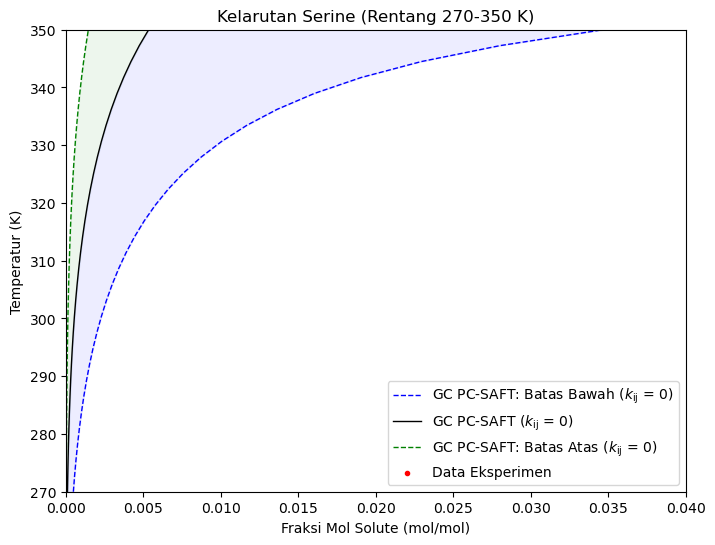

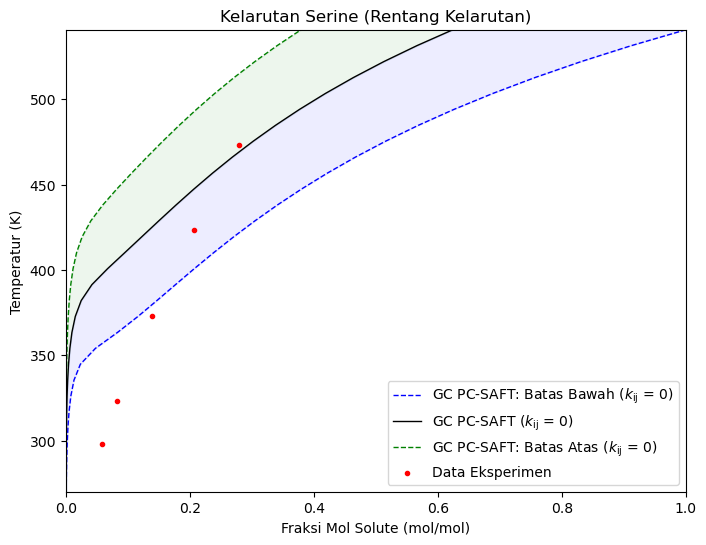

In [32]:
using Clapeyron
using CSV
using DataFrames

df_eksperimen = CSV.read("fig_serine.csv", DataFrame)

function plot_T(df)
    T = LinRange(270., 350., 30)
    p = 101325
    s_low = zeros(length(T))
    s_mid = zeros(length(T))
    s_up = zeros(length(T))

    
    for i in 1:length(T)
        s_low[i] = sle_solubility(model5_low, p, T[i], [1., 1.]; solute=["serine_gclow"])[2]
        s_mid[i] = sle_solubility(model5_mid, p, T[i], [1., 1.]; solute=["serine_gcmid"])[2]
        s_up[i]  = sle_solubility(model5_up, p, T[i], [1., 1.]; solute=["serine_gcup"])[2]
    end

    plt.figure(figsize=(8, 6))
    
    plt.plot(s_low, T, label=L"GC PC-SAFT: Batas Bawah ($k_{\text{ij}}$ = 0)", color="blue", linestyle="--", linewidth=1.)
    plt.plot(s_mid, T, label=L"GC PC-SAFT ($k_{\text{ij}}$ = 0)", color="black", linestyle="-", linewidth=1.)
    plt.plot(s_up, T, label=L"GC PC-SAFT: Batas Atas ($k_{\text{ij}}$ = 0)", color="green", linestyle="--", linewidth=1.)

    plt.fill_betweenx(T, s_mid, s_up, color="green", alpha=0.07)
    plt.fill_betweenx(T, s_low, s_mid, color="blue", alpha=0.07)

    plt.scatter(df.out_x2, df.T, label="Data Eksperimen", color="red", marker=".", zorder=1)
    
    plt.title("Kelarutan Serine (Rentang 270-350 K)")
    plt.xlabel("Fraksi Mol Solute (mol/mol)")
    plt.ylabel("Temperatur (K)")
    
    plt.xlim(0.0, 0.04)
    plt.ylim(270.0, 350.0)
    
    plt.legend(loc="lower right")
    plt.savefig("5_plot_T_serine.png", dpi=450, bbox_inches="tight") #GANTI NAMANYA DULU
end

function plot_x(df)
    T = LinRange(270., model5_low.solid.params.Tm[2], 30)
    p = 101325
    
    s_low = zeros(length(T))
    s_mid = zeros(length(T))
    s_up = zeros(length(T))
    
    for i in 1:length(T)
        s_low[i] = sle_solubility(model5_low, p, T[i], [1., 1.]; solute=["serine_gclow"])[2]
        s_mid[i] = sle_solubility(model5_mid, p, T[i], [1., 1.]; solute=["serine_gcmid"])[2]
        s_up[i]  = sle_solubility(model5_up, p, T[i], [1., 1.]; solute=["serine_gcup"])[2]
    end

    # Bikin DataFrame-nya dulu
    df_hasil = DataFrame(
        Temperatur_K = T,
        X_Low = s_low,
        X_Mid = s_mid,
        X_Up = s_up)
    # Tampilkan di output terminal
    println("\n=== HASIL PERHITUNGAN MODEL ===")
    show(df_hasil, allrows=true)
    println("\n")

    plt.figure(figsize=(8, 6))
    
    plt.plot(s_low, T, label=L"GC PC-SAFT: Batas Bawah ($k_{\text{ij}}$ = 0)", color="blue", linestyle="--", linewidth=1.)
    plt.plot(s_mid, T, label=L"GC PC-SAFT ($k_{\text{ij}}$ = 0)", color="black", linestyle="-", linewidth=1.)
    plt.plot(s_up, T, label=L"GC PC-SAFT: Batas Atas ($k_{\text{ij}}$ = 0)", color="green", linestyle="--", linewidth=1.)

    plt.fill_betweenx(T, s_mid, s_up, color="green", alpha=0.07)
    plt.fill_betweenx(T, s_low, s_mid, color="blue", alpha=0.07)

    plt.scatter(df.out_x2, df.T, label="Data Eksperimen", color="red", marker=".", zorder=1)
    
    plt.title("Kelarutan Serine (Rentang Kelarutan)")
    plt.xlabel("Fraksi Mol Solute (mol/mol)")
    plt.ylabel("Temperatur (K)")
    
    plt.xlim(0.0, 1)
    plt.ylim(270.0, model5_low.solid.params.Tm[2])
    
    plt.legend(loc="lower right")
    plt.savefig("5_plot_x_serine.png", dpi=450, bbox_inches="tight") #GANTI NAMANYA DULU
end

plot_T(df_eksperimen)
plot_x(df_eksperimen)

In [33]:
aard_p   = calculate_AAD(model5_low, "sol_serine.csv", solubility_gclow)

┌ Warning: thread = 1 warning: parsed expected 1 columns, but didn't reach end of line around data row: 1. Parsing extra columns and widening final columnset
└ @ CSV C:\Users\sutha\.julia\packages\CSV\XLcqT\src\file.jl:593



=== AAD: sol_serine.csv ===
Clapeyron Estimator  exp           calc          ARD%    
298.1500    0.059009      0.002057      96.5148 
323.1500    0.081925      0.006852      91.6364 
373.1500    0.138613      0.117610      15.1525 
423.1500    0.207127      0.284097      37.1609 
473.1500    0.279037      0.503298      80.3698 
AARD = 64.1669%


64.16687145301056

In [34]:
aard_p   = calculate_AAD(model5_mid, "sol_serine.csv", solubility_gcmid)


=== AAD: sol_serine.csv ===
Clapeyron Estimator  exp           calc          ARD%    
298.1500    0.059009      0.000490      99.1704 
323.1500    0.081925      0.001633      98.0066 
373.1500    0.138613      0.015442      88.8599 
423.1500    0.207127      0.133266      35.6595 
473.1500    0.279037      0.293625      5.2281  
AARD = 65.3849%


┌ Warning: thread = 1 warning: parsed expected 1 columns, but didn't reach end of line around data row: 1. Parsing extra columns and widening final columnset
└ @ CSV C:\Users\sutha\.julia\packages\CSV\XLcqT\src\file.jl:593


65.38489408461392

In [35]:
aard_p   = calculate_AAD(model5_up, "sol_serine.csv", solubility_gcup)


=== AAD: sol_serine.csv ===
Clapeyron Estimator  exp           calc          ARD%    
298.1500    0.059009      0.000115      99.8058 
323.1500    0.081925      0.000427      99.4792 
373.1500    0.138613      0.003765      97.2839 
423.1500    0.207127      0.031075      84.9970 
473.1500    0.279037      0.149903      46.2784 
AARD = 85.5689%


┌ Warning: thread = 1 warning: parsed expected 1 columns, but didn't reach end of line around data row: 1. Parsing extra columns and widening final columnset
└ @ CSV C:\Users\sutha\.julia\packages\CSV\XLcqT\src\file.jl:593


85.56886587791169

# 6
- pure comp: GC
- kij: molecular (VLE GC)
- melting: GC

In [36]:
#Hfus dan Tm masukin ke csv yh jgn lupa

like_parameter6 = """Clapeyron Database File
PCSAFT Like Parameters [csvtype = like,grouptype = PCSAFT]
species,Mw,segment,sigma,epsilon,n_H,n_e
serine_gclow,105.09,7.0236,2.284,236.92,2,2
serine_gcmid,105.09,7.0236,2.284,236.92,2,2
serine_gcup,105.09,7.0236,2.284,236.92,2,2
water,18.02,1.2047,2.801457,353.94,1,1
"""
# GC glycine1,75.07,4.8492,2.2140,238.6085,2,2 
# Held glycine1,75.07,4.8495,2.3270,216.9600,2,2 

unlike_parameter6 = """Clapeyron Database File
PCSAFT Unlike Parameters [csvtype = unlike,grouptype = PCSAFT]
species1,species2,k
water,serine_gclow,0.190076
water,serine_gcmid,0.190076
water,serine_gcup,0.190076
"""

# GC kij = 0.0000296035176
# Held kij = -0.0612

#jgn lupa combing rules yh
assoc_parameter6 = """Clapeyron Database File
PCSAFT Assoc Parameters [csvtype = assoc,grouptype = PCSAFT]
species1,site1,species2,site2,epsilon_assoc,bondvol
water,H,water,e,2425.67,0.045
serine_gclow,H,serine_gclow,e,2086.933118,0.032905
serine_gcmid,H,serine_gcmid,e,2086.933118,0.032905
serine_gcup,H,serine_gcup,e,2086.933118,0.032905
water,H,serine_gclow,e,2256.302,0.037884
water,e,serine_gclow,H,2256.302,0.037884
water,H,serine_gcmid,e,2256.302,0.037884
water,e,serine_gcmid,H,2256.302,0.037884
water,H,serine_gcup,e,2256.302,0.037884
water,e,serine_gcup,H,2256.302,0.037884
"""
components_low = ["water", "serine_gclow"]
components_mid = ["water", "serine_gcmid"]
components_up = ["water", "serine_gcup"]

model6_low = CompositeModel(components_low;
                       fluid = PCSAFT,
                       solid = SolidHfus,
                       fluid_userlocations = [like_parameter6, unlike_parameter6, assoc_parameter6])
model6_mid = CompositeModel(components_mid;
                       fluid = PCSAFT,
                       solid = SolidHfus,
                       fluid_userlocations = [like_parameter6, unlike_parameter6, assoc_parameter6])
model6_up = CompositeModel(components_up;
                       fluid = PCSAFT,
                       solid = SolidHfus,
                       fluid_userlocations = [like_parameter6, unlike_parameter6, assoc_parameter6])


println("low bound")
println("Hfus = ", model6_low.solid.params.Hfus[2])
println("Tm = ", model6_low.solid.params.Tm[2])

println("mid bound")
println("Hfus = ", model6_mid.solid.params.Hfus[2])
println("Tm = ", model6_mid.solid.params.Tm[2])

println("up bound")
println("Hfus = ", model6_up.solid.params.Hfus[2])
println("Tm = ", model6_up.solid.params.Tm[2])

low bound
Hfus = 23931.34
Tm = 540.7812
mid bound
Hfus = 28626.0
Tm = 587.17
up bound
Hfus = 33320.66
Tm = 633.5536



=== HASIL PERHITUNGAN MODEL ===
100×4 DataFrame
 Row │ Temperatur_K  X_Low        X_Mid        X_Up        
     │ Float64       Float64      Float64      Float64     
─────┼─────────────────────────────────────────────────────
   1 │      270.0    5.5684e-10   1.18174e-10  2.31697e-11
   2 │      272.735  7.56624e-10  1.63976e-10  3.28313e-11
   3 │      275.47   1.02165e-9   2.26011e-10  4.61918e-11
   4 │      278.205  1.37115e-9   3.09501e-10  6.4543e-11
   5 │      280.941  1.82937e-9   4.21174e-10  8.95839e-11
   6 │      283.676  2.4268e-9    5.69653e-10  1.23536e-10
   7 │      286.411  3.20153e-9   7.65928e-10  1.69288e-10
   8 │      289.146  4.20088e-9   1.02393e-9   2.30573e-10
   9 │      291.881  5.48345e-9   1.36123e-9   3.12188e-10
  10 │      294.616  7.12136e-9   1.79986e-9   4.20266e-10
  11 │      297.352  9.20306e-9   2.36736e-9   5.62608e-10
  12 │      300.087  1.18365e-8   3.09794e-9   7.49083e-10
  13 │      302.822  1.51529e-8   4.0339e-9    9.92117e-10
  14 

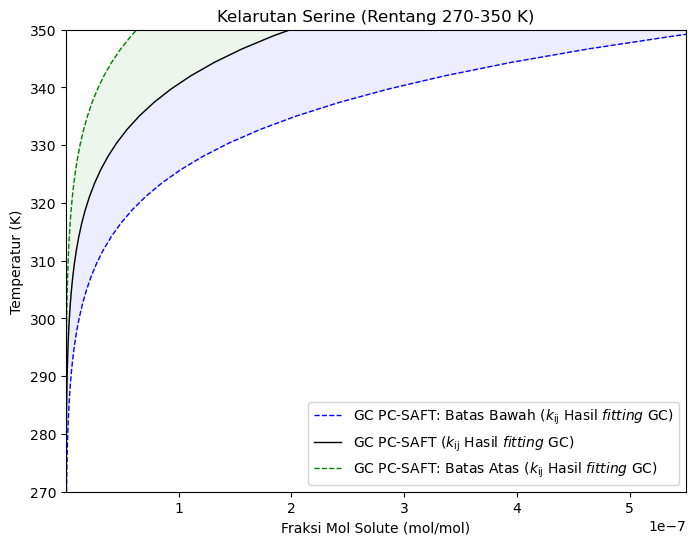

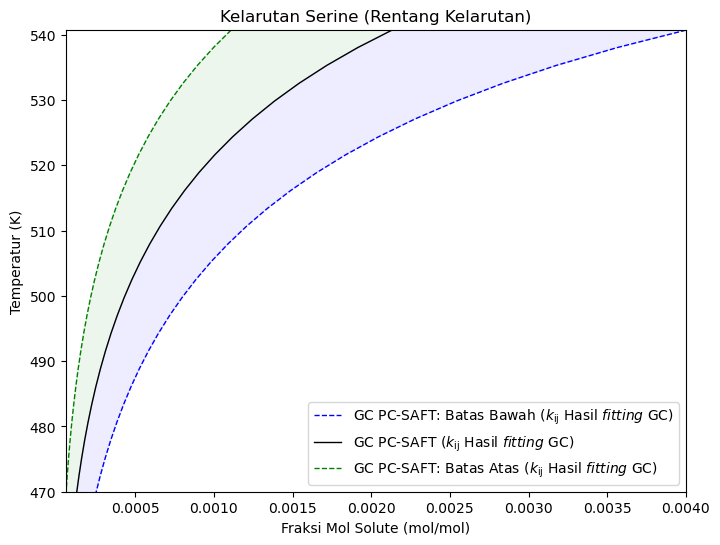

In [44]:
using Clapeyron
using CSV
using DataFrames

df_eksperimen = CSV.read("fig_serine.csv", DataFrame)

function plot_T(df)
    T = LinRange(270., 500., 100)
    p = 101325
    s_low = zeros(length(T))
    s_mid = zeros(length(T))
    s_up = zeros(length(T))

    
    for i in 1:length(T)
        s_low[i] = sle_solubility(model6_low, p, T[i], [1., 1.]; solute=["serine_gclow"])[2]
        s_mid[i] = sle_solubility(model6_mid, p, T[i], [1., 1.]; solute=["serine_gcmid"])[2]
        s_up[i]  = sle_solubility(model6_up, p, T[i], [1., 1.]; solute=["serine_gcup"])[2]
    end

    plt.figure(figsize=(8, 6))
    
    plt.plot(s_low, T, label=L"GC PC-SAFT: Batas Bawah ($k_{\text{ij}}$ Hasil $fitting$ GC)", color="blue", linestyle="--", linewidth=1.)
    plt.plot(s_mid, T, label=L"GC PC-SAFT ($k_{\text{ij}}$ Hasil $fitting$ GC)", color="black", linestyle="-", linewidth=1.)
    plt.plot(s_up, T, label=L"GC PC-SAFT: Batas Atas ($k_{\text{ij}}$ Hasil $fitting$ GC)", color="green", linestyle="--", linewidth=1.)

    plt.fill_betweenx(T, s_mid, s_up, color="green", alpha=0.07)
    plt.fill_betweenx(T, s_low, s_mid, color="blue", alpha=0.07)

    plt.scatter(df.out_x2, df.T, color="red", marker=".", zorder=1)
    
    plt.title("Kelarutan Serine (Rentang 270-350 K)")
    plt.xlabel("Fraksi Mol Solute (mol/mol)")
    plt.ylabel("Temperatur (K)")
    
    plt.xlim(2.3e-11, 5.5e-7)
    plt.ylim(270.0, 350.0)
    
    plt.legend(loc="lower right")
    plt.savefig("6_plot_T_serine.png", dpi=450, bbox_inches="tight") #GANTI NAMANYA DULU
end

function plot_x(df)
    T = LinRange(270., model6_low.solid.params.Tm[2], 100)
    p = 101325
    
    s_low = zeros(length(T))
    s_mid = zeros(length(T))
    s_up = zeros(length(T))
    
    for i in 1:length(T)
        s_low[i] = sle_solubility(model6_low, p, T[i], [1., 1.]; solute=["serine_gclow"])[2]
        s_mid[i] = sle_solubility(model6_mid, p, T[i], [1., 1.]; solute=["serine_gcmid"])[2]
        s_up[i]  = sle_solubility(model6_up, p, T[i], [1., 1.]; solute=["serine_gcup"])[2]
    end

    # Bikin DataFrame-nya dulu
    df_hasil = DataFrame(
        Temperatur_K = T,
        X_Low = s_low,
        X_Mid = s_mid,
        X_Up = s_up)
    # Tampilkan di output terminal
    println("\n=== HASIL PERHITUNGAN MODEL ===")
    show(df_hasil, allrows=true)
    println("\n")

    plt.figure(figsize=(8, 6))
    
    plt.plot(s_low, T, label=L"GC PC-SAFT: Batas Bawah ($k_{\text{ij}}$ Hasil $fitting$ GC)", color="blue", linestyle="--", linewidth=1.)
    plt.plot(s_mid, T, label=L"GC PC-SAFT ($k_{\text{ij}}$ Hasil $fitting$ GC)", color="black", linestyle="-", linewidth=1.)
    plt.plot(s_up, T, label=L"GC PC-SAFT: Batas Atas ($k_{\text{ij}}$ Hasil $fitting$ GC)", color="green", linestyle="--", linewidth=1.)

    plt.fill_betweenx(T, s_mid, s_up, color="green", alpha=0.07)
    plt.fill_betweenx(T, s_low, s_mid, color="blue", alpha=0.07)

    plt.scatter(df.out_x2, df.T, color="red", marker=".", zorder=1)
    
    plt.title("Kelarutan Serine (Rentang Kelarutan)")
    plt.xlabel("Fraksi Mol Solute (mol/mol)")
    plt.ylabel("Temperatur (K)")
    
    plt.xlim(6e-5, 0.004)
    plt.ylim(470.0, model6_low.solid.params.Tm[2])
    
    plt.legend(loc="lower right")
    plt.savefig("6_plot_x_serine.png", dpi=450, bbox_inches="tight") #GANTI NAMANYA DULU
end

plot_T(df_eksperimen)
plot_x(df_eksperimen)

In [45]:
aard_p   = calculate_AAD(model6_low, "sol_serine.csv", solubility_gclow)

┌ Warning: thread = 1 warning: parsed expected 1 columns, but didn't reach end of line around data row: 1. Parsing extra columns and widening final columnset
└ @ CSV C:\Users\sutha\.julia\packages\CSV\XLcqT\src\file.jl:593



=== AAD: sol_serine.csv ===
Clapeyron Estimator  exp           calc          ARD%    
298.1500    0.059009      0.000000      100.0000
323.1500    0.081925      0.000000      99.9999 
373.1500    0.138613      0.000002      99.9982 
423.1500    0.207127      0.000034      99.9836 
473.1500    0.279037      0.000286      99.8974 
AARD = 99.9758%


99.97583192880423

In [46]:
aard_p   = calculate_AAD(model6_mid, "sol_serine.csv", solubility_gcmid)


=== AAD: sol_serine.csv ===
Clapeyron Estimator  exp           calc          ARD%    
298.1500    0.059009      0.000000      100.0000
323.1500    0.081925      0.000000      100.0000
373.1500    0.138613      0.000001      99.9993 
423.1500    0.207127      0.000015      99.9926 
473.1500    0.279037      0.000147      99.9472 
AARD = 99.9878%


┌ Warning: thread = 1 warning: parsed expected 1 columns, but didn't reach end of line around data row: 1. Parsing extra columns and widening final columnset
└ @ CSV C:\Users\sutha\.julia\packages\CSV\XLcqT\src\file.jl:593


99.98782129567635

In [47]:
aard_p   = calculate_AAD(model6_up, "sol_serine.csv", solubility_gcup)


=== AAD: sol_serine.csv ===
Clapeyron Estimator  exp           calc          ARD%    
298.1500    0.059009      0.000000      100.0000
323.1500    0.081925      0.000000      100.0000
373.1500    0.138613      0.000000      99.9998 
423.1500    0.207127      0.000006      99.9969 
473.1500    0.279037      0.000070      99.9748 
AARD = 99.9943%


┌ Warning: thread = 1 warning: parsed expected 1 columns, but didn't reach end of line around data row: 1. Parsing extra columns and widening final columnset
└ @ CSV C:\Users\sutha\.julia\packages\CSV\XLcqT\src\file.jl:593


99.9942861313745